# Walkthrough - Raw Messy Trajectory to a Clean, Feature-Rich Representation

A realistic mess: lat/lon in degrees, irregular timestamps, duplicates, out-of-order records,
dropouts and a few impossible positions. We turn it into something modellable, and at each step we
ask the two questions from Chapter 3:

* **which models does this choice make feasible downstream?**
* **which biases and artifacts does it introduce?**

Companion lessons: [L01](../lessons/L01_irregular_sampling.md),
[L02](../lessons/L02_frames_and_features.md), [L03](../lessons/L03_segmentation.md).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

RNG = np.random.default_rng(3)
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": 0.3})

## Part 1 - Simulate a raw feed

Truth: a flight from a point near (32.0 N, 34.9 E) that cruises, turns, holds, then cruises out.
The recorder is imperfect in all the usual ways.

In [2]:
DT, T = 1.0, 900
LAT0, LON0 = 32.0, 34.9

# --- truth in a local ENU frame (metres), built from a turn-rate profile ---
omega = np.zeros(T)
omega[300:360] = 0.035           # first turn
omega[520:700] = 0.05            # a holding pattern
speed = np.full(T, 220.0)
speed[430:520] = 150.0           # slow down before the hold
hdg = np.cumsum(omega * DT) + 0.6
vel = np.c_[speed * np.cos(hdg), speed * np.sin(hdg)]
enu_true = np.cumsum(vel * DT, axis=0)

# --- convert to lat/lon so we start where a real feed starts ---
M_PER_DEG_LAT = 111_320.0
m_per_deg_lon = M_PER_DEG_LAT * np.cos(np.deg2rad(LAT0))
lat = LAT0 + enu_true[:, 1] / M_PER_DEG_LAT
lon = LON0 + enu_true[:, 0] / m_per_deg_lon
t = np.arange(T, dtype=float)

# --- corrupt it: sensor noise, dropouts, jitter, duplicates, disorder, outliers ---
lat_n = lat + RNG.normal(0, 40 / M_PER_DEG_LAT, T)
lon_n = lon + RNG.normal(0, 40 / m_per_deg_lon, T)
keep = np.ones(T, bool)
keep[RNG.random(T) < 0.25] = False              # 25% random dropout
keep[610:690] = False                           # one long outage inside the hold
raw_t, raw_lat, raw_lon = t[keep], lat_n[keep], lon_n[keep]
raw_t = raw_t + RNG.normal(0, 0.15, raw_t.size)  # timestamp jitter

dup = RNG.choice(raw_t.size, 20, replace=False)  # duplicated records
raw_t = np.r_[raw_t, raw_t[dup]]
raw_lat = np.r_[raw_lat, raw_lat[dup]]
raw_lon = np.r_[raw_lon, raw_lon[dup]]

out = RNG.choice(raw_t.size, 8, replace=False)   # impossible jumps
raw_lat[out] += RNG.normal(0, 0.05, 8)
raw_lon[out] += RNG.normal(0, 0.05, 8)

order = RNG.permutation(raw_t.size)              # arrives out of order
raw_t, raw_lat, raw_lon = raw_t[order], raw_lat[order], raw_lon[order]

print(f"raw records: {raw_t.size}   time range: {raw_t.min():.1f}..{raw_t.max():.1f} s")
print("first five records, as they arrive:")
for i in range(5):
    print(f"  t={raw_t[i]:8.2f}  lat={raw_lat[i]:.5f}  lon={raw_lon[i]:.5f}")

raw records: 621   time range: 0.1..898.8 s
first five records, as they arrive:
  t=  591.06  lat=32.46786  lon=35.17215
  t=  449.57  lat=32.50348  lon=35.28827
  t=  736.84  lat=32.42338  lon=35.19302
  t=  341.97  lat=32.40998  lon=35.49615
  t=  398.97  lat=32.46588  lon=35.38132


## Part 2 - Clean: sort, deduplicate, sanity-check

Do this before *anything* else. Every downstream computation assumes a monotone time axis.

after sort + dedup: 601 records
median dt 1.09s   90th pct 2.25s   max 83.3s


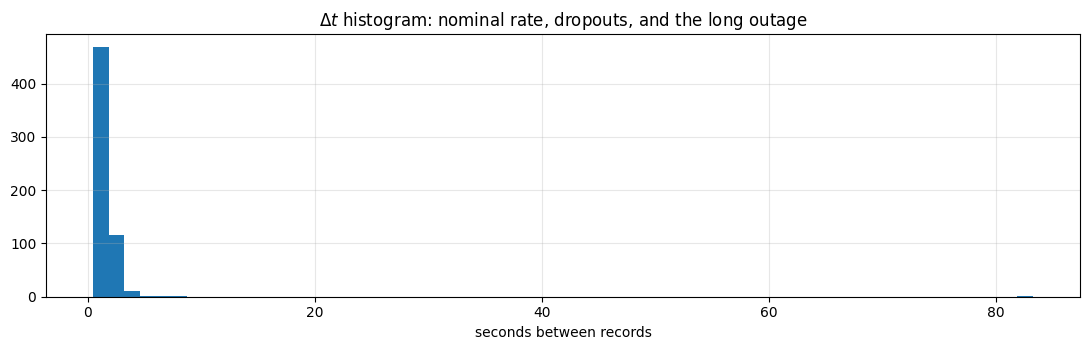

In [3]:
idx = np.argsort(raw_t)
tt, la, lo = raw_t[idx], raw_lat[idx], raw_lon[idx]
uniq = np.r_[True, np.diff(tt) > 1e-6]           # drop duplicate timestamps
tt, la, lo = tt[uniq], la[uniq], lo[uniq]
print(f"after sort + dedup: {tt.size} records")

dts = np.diff(tt)
plt.hist(dts, bins=60)
plt.title("$\\Delta t$ histogram: nominal rate, dropouts, and the long outage")
plt.xlabel("seconds between records")
plt.tight_layout()
print(f"median dt {np.median(dts):.2f}s   90th pct {np.percentile(dts, 90):.2f}s   max {dts.max():.1f}s")

## Part 3 - Get out of degrees: a local ENU frame

Latitude and longitude degrees are not the same length, and neither is a metre. Convert once, at
the start, and do every kinematic computation in metres (Chapter 3 Lesson 02).

In [4]:
def to_enu(lat_deg, lon_deg, lat0=LAT0, lon0=LON0):
    """Equirectangular local tangent plane - fine over a few hundred km."""
    e = (lon_deg - lon0) * M_PER_DEG_LAT * np.cos(np.deg2rad(lat0))
    n = (lat_deg - lat0) * M_PER_DEG_LAT
    return np.c_[e, n]


enu = to_enu(la, lo)

# what happens if you forget: treat degrees as a plane and scale by a single constant
naive = np.c_[(lo - LON0), (la - LAT0)] * M_PER_DEG_LAT
seg_true = np.linalg.norm(np.diff(to_enu(lat, lon), axis=0), axis=1).sum()
seg_naive = np.linalg.norm(np.diff(naive, axis=0), axis=1).sum()
print(f"path length, correct frame: {seg_true / 1000:8.1f} km")
print(f"path length, degrees-as-metres: {seg_naive / 1000:8.1f} km"
      f"   ({100 * (seg_naive / seg_true - 1):+.0f}% error at latitude {LAT0})")

path length, correct frame:    191.5 km
path length, degrees-as-metres:    351.9 km   (+84% error at latitude 32.0)


## Part 4 - Outliers: gate them, do not smooth over them

A physically impossible speed between consecutive reports is not noise, it is a bad record.
Removing it *before* filtering is much safer than hoping the filter's gain will absorb it.

In [5]:
V_MAX = 400.0                                    # m/s, generous for this platform
step_v = np.r_[0, np.linalg.norm(np.diff(enu, axis=0), axis=1) / np.diff(tt)]
bad = step_v > V_MAX
print(f"rejected {bad.sum()} records with implied speed > {V_MAX} m/s "
      f"(max implied speed was {step_v.max():.0f} m/s)")
tt, enu = tt[~bad], enu[~bad]

rejected 30 records with implied speed > 400.0 m/s (max implied speed was 17423 m/s)


## Part 5 - Segment at real gaps

A 78-second outage is not something to interpolate across; bridging it fabricates a straight leg
and two corners. Split there instead, and let downstream code see two segments.

In [6]:
GAP = 20.0                                       # seconds; longer than any plausible dropout
breaks = np.where(np.diff(tt) > GAP)[0] + 1
segments = np.split(np.arange(tt.size), breaks)
print(f"{len(segments)} segments: " + ", ".join(f"{len(s)} pts" for s in segments))

2 segments: 419 pts, 152 pts


## Part 6 - Model-based smoothing with irregular $\Delta t$

The right resampler for kinematic data is a Kalman filter with $F(\Delta t)$ and $Q(\Delta t)$
recomputed at every step (Chapter 2 Lesson 01, Chapter 3 Lesson 01), followed by an RTS backward
pass. It gives velocity directly — no finite differences on noisy positions — and it reports its
own uncertainty, so downstream code knows which points were guessed.

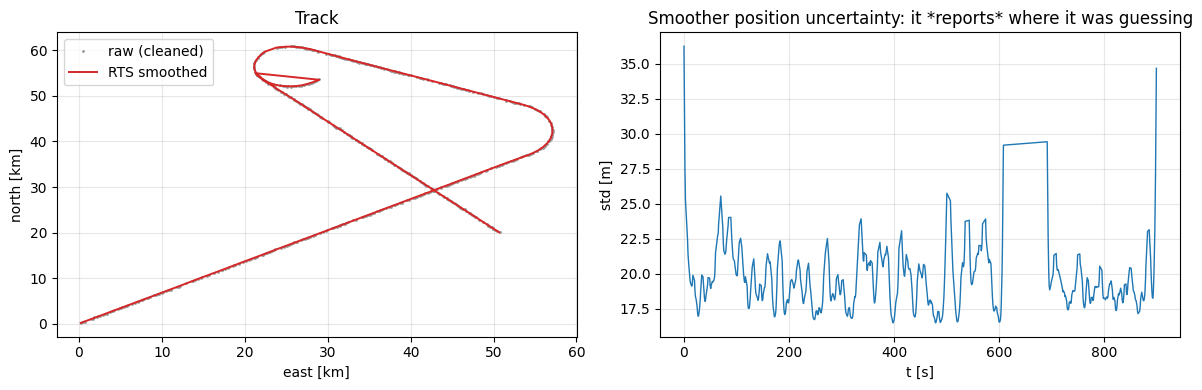

In [7]:
def kalman_rts(times, pos, sa=2.0, r_std=40.0):
    """CV Kalman filter + RTS smoother on irregular timestamps. State (px, vx, py, vy)."""
    n = len(times)
    H = np.array([[1.0, 0, 0, 0], [0, 0, 1.0, 0]])
    R = r_std ** 2 * np.eye(2)
    xf = np.zeros((n, 4))
    Pf = np.zeros((n, 4, 4))
    xp = np.zeros((n, 4))
    Pp = np.zeros((n, 4, 4))
    Fs = np.zeros((n, 4, 4))
    x = np.array([pos[0, 0], 0.0, pos[0, 1], 0.0])
    P = np.diag([100.0 ** 2, 200.0 ** 2, 100.0 ** 2, 200.0 ** 2])
    for k in range(n):
        dt = times[k] - times[k - 1] if k else 1.0
        F = np.array([[1, dt, 0, 0], [0, 1, 0, 0], [0, 0, 1, dt], [0, 0, 0, 1]])
        G = np.array([[dt ** 2 / 2, 0], [dt, 0], [0, dt ** 2 / 2], [0, dt]])
        Q = sa ** 2 * G @ G.T
        x, P = F @ x, F @ P @ F.T + Q
        Fs[k], xp[k], Pp[k] = F, x, P
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)
        x = x + K @ (pos[k] - H @ x)
        IKH = np.eye(4) - K @ H
        P = IKH @ P @ IKH.T + K @ R @ K.T
        xf[k], Pf[k] = x, P
    # RTS backward pass
    xs, Ps = xf.copy(), Pf.copy()
    for k in range(n - 2, -1, -1):
        C = Pf[k] @ Fs[k + 1].T @ np.linalg.inv(Pp[k + 1])
        xs[k] = xf[k] + C @ (xs[k + 1] - xp[k + 1])
        Ps[k] = Pf[k] + C @ (Ps[k + 1] - Pp[k + 1]) @ C.T
    return xs, Ps


states, covs = [], []
for s in segments:
    xs, Ps = kalman_rts(tt[s], enu[s])
    states.append(xs)
    covs.append(Ps)
state = np.vstack(states)
cov = np.vstack(covs)
pos_std = np.sqrt(cov[:, 0, 0] + cov[:, 2, 2])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(enu[:, 0] / 1000, enu[:, 1] / 1000, ".", ms=2, color="0.6", label="raw (cleaned)")
ax[0].plot(state[:, 0] / 1000, state[:, 2] / 1000, "-", lw=1.4, color="tab:red", label="RTS smoothed")
ax[0].legend(); ax[0].set_xlabel("east [km]"); ax[0].set_ylabel("north [km]"); ax[0].set_title("Track")
ax[1].plot(tt, pos_std, lw=1)
ax[1].set_title("Smoother position uncertainty: it *reports* where it was guessing")
ax[1].set_xlabel("t [s]"); ax[1].set_ylabel("std [m]")
plt.tight_layout()

## Part 7 - Kinematic features, done correctly

Speed, heading, turn rate and curvature — from the **smoothed state**, never from finite
differences on raw positions. The comparison below is the whole argument.

speed error, naive differences:    61.1 m/s
speed error, smoothed state:        4.9 m/s


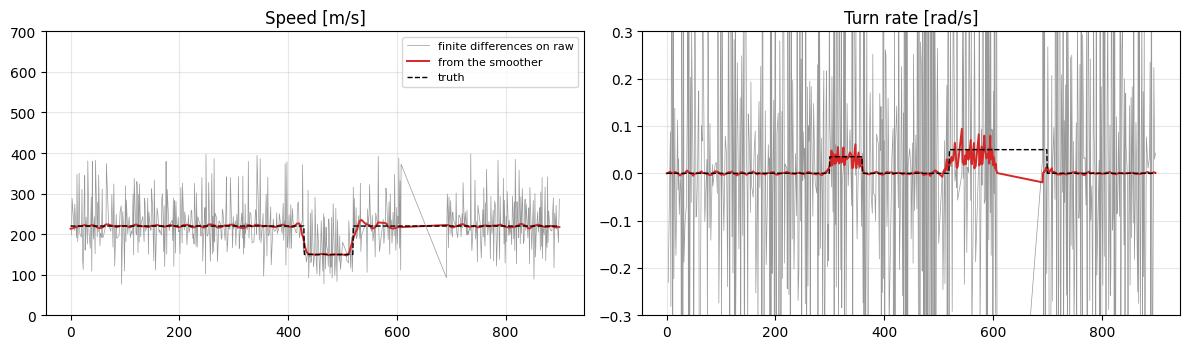

In [8]:
vx, vy = state[:, 1], state[:, 3]
speed_f = np.hypot(vx, vy)
hdg_f = np.unwrap(np.arctan2(vy, vx))
turn_f = np.r_[0, np.diff(hdg_f) / np.maximum(np.diff(tt), 1e-3)]

# the naive version, for comparison
d = np.diff(enu, axis=0)
dt_raw = np.maximum(np.diff(tt), 1e-3)
speed_raw = np.r_[np.nan, np.linalg.norm(d, axis=1) / dt_raw]
hdg_raw = np.r_[np.nan, np.unwrap(np.arctan2(d[:, 1], d[:, 0]))]
turn_raw = np.r_[np.nan, np.nan, np.diff(hdg_raw[1:]) / dt_raw[1:]]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(tt, speed_raw, lw=0.5, color="0.6", label="finite differences on raw")
ax[0].plot(tt, speed_f, lw=1.4, color="tab:red", label="from the smoother")
ax[0].plot(t, speed, "k--", lw=1, label="truth")
ax[0].set_ylim(0, 700); ax[0].legend(fontsize=8); ax[0].set_title("Speed [m/s]")
ax[1].plot(tt, turn_raw, lw=0.5, color="0.6")
ax[1].plot(tt, turn_f, lw=1.4, color="tab:red")
ax[1].plot(t, omega, "k--", lw=1)
ax[1].set_ylim(-0.3, 0.3); ax[1].set_title("Turn rate [rad/s]")
plt.tight_layout()

print(f"speed error, naive differences: {np.nanstd(speed_raw - np.interp(tt, t, speed)):7.1f} m/s")
print(f"speed error, smoothed state:    {np.nanstd(speed_f - np.interp(tt, t, speed)):7.1f} m/s")

Differentiating noisy positions turns a 40 m position error into a ~60 m/s speed error and a turn
rate that is pure noise — the true signal (0.035-0.05 rad/s) is invisible in it. Any classifier
fed the grey curve is learning the sensor, not the aircraft.

## Part 8 - Segmentation by change point

Now that turn rate is a usable signal, segment the flight into behaviour phases. We implement
exact dynamic-programming segmentation with a per-change-point penalty $\beta$ — the objective
from Chapter 3 Lesson 03. (`ruptures` gives you PELT's linear-time pruning; the objective is the
same.)

change points at t = ['299s', '360s', '515s', '543s', '603s']


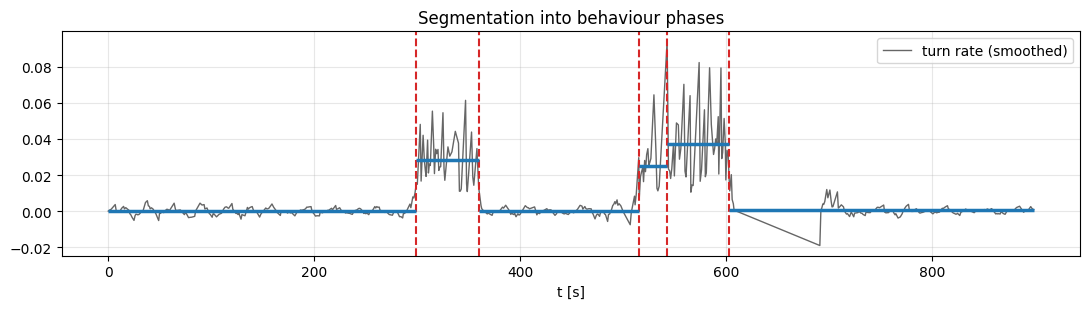

In [9]:
def segment_dp(y, beta, min_size=15):
    """Exact least-squares change-point detection: min sum-of-squares + beta * (#changes)."""
    n = len(y)
    cs, cs2 = np.r_[0, np.cumsum(y)], np.r_[0, np.cumsum(y ** 2)]

    def cost(a, b):                                    # SSE of y[a:b]
        m = b - a
        return cs2[b] - cs2[a] - (cs[b] - cs[a]) ** 2 / m

    C = np.full(n + 1, np.inf)
    C[0] = -beta
    prev = np.zeros(n + 1, int)
    for b in range(min_size, n + 1):
        for a in range(0, b - min_size + 1):
            if np.isfinite(C[a]):
                v = C[a] + cost(a, b) + beta
                if v < C[b]:
                    C[b], prev[b] = v, a
    cps, b = [], n
    while b > 0:
        cps.append(b)
        b = prev[b]
    return sorted(cps)[:-1]


sig = (turn_f - turn_f.mean()) / turn_f.std()          # standardise: beta then has a scale
cps = segment_dp(sig, beta=8.0)
print("change points at t =", [f"{tt[c]:.0f}s" for c in cps])

plt.figure(figsize=(11, 3.2))
plt.plot(tt, turn_f, lw=1, color="0.4", label="turn rate (smoothed)")
for c in cps:
    plt.axvline(tt[c], color="tab:red", ls="--")
edges = [0] + cps + [len(tt)]
for a, b in zip(edges[:-1], edges[1:]):
    plt.hlines(turn_f[a:b].mean(), tt[a], tt[min(b, len(tt) - 1)], color="tab:blue", lw=2.5)
plt.legend(); plt.title("Segmentation into behaviour phases"); plt.xlabel("t [s]")
plt.tight_layout()

### $\beta$ is the number-of-segments knob — sweep it, do not trust a default

In [10]:
for beta in [2, 4, 8, 16, 40, 100]:
    print(f"beta={beta:>4}  ->  {len(segment_dp(sig, beta=beta)) + 1:>2} segments")

beta=   2  ->   7 segments
beta=   4  ->   6 segments


beta=   8  ->   6 segments
beta=  16  ->   5 segments


beta=  40  ->   5 segments
beta= 100  ->   3 segments


## Part 9 - The segment table: the actual deliverable

One row per segment, with duration, kinematics, and a data-quality column. This is what feeds
Chapter 4 (classification) and Chapter 5 (anomaly detection), and the quality column is what stops
you from "discovering" your own dropouts.

In [11]:
print(f"{'seg':>4}{'t0':>8}{'dur':>7}{'speed':>8}{'|turn|':>9}{'straight':>10}{'gap frac':>10}")
for i, (a, b) in enumerate(zip(edges[:-1], edges[1:])):
    b = min(b, len(tt) - 1)
    if b - a < 5:
        continue
    p = state[a:b, [0, 2]]
    path = np.linalg.norm(np.diff(p, axis=0), axis=1).sum()
    straight = np.linalg.norm(p[-1] - p[0]) / max(path, 1e-9)
    gapfrac = 1 - (b - a) / max(tt[b] - tt[a], 1e-9)          # 1 - records per second
    print(f"{i:>4}{tt[a]:>8.0f}{tt[b] - tt[a]:>7.0f}{speed_f[a:b].mean():>8.0f}"
          f"{np.abs(turn_f[a:b]).mean():>9.3f}{straight:>10.2f}{gapfrac:>10.2f}")

 seg      t0    dur   speed   |turn|  straight  gap frac
   0       0    299     220    0.002      1.00      0.31
   1     299     61     219    0.028      0.83      0.32
   2     360    155     180    0.002      1.00      0.31
   3     515     28     203    0.025      0.98      0.35
   4     543     60     220    0.037      0.68      0.32
   5     603    296     220    0.002      0.73      0.47


## What each choice cost us

| Choice | Makes feasible | Introduces |
| --- | --- | --- |
| Sort + dedup + speed gate | everything downstream | a `V_MAX` threshold that could reject a real, extreme maneuver |
| Local ENU frame | Euclidean distances, motion models, $Q$ in m²/s³ | projection error away from the origin (small here, not always) |
| Split at gaps > 20 s | honest segments, no fabricated legs | more, shorter segments; a threshold to defend |
| Kalman/RTS smoothing | clean velocity, turn rate, curvature; uncertainty per point | a CV motion-model prior — real maneuvers are slightly flattened |
| Change-point segmentation | per-phase features, Markov/HMM models over phases | $\beta$ chooses the number of segments; boundaries are estimates |
| Segment feature table | tabular ML, the Chapter 0 baseline | all within-segment ordering is gone |

**And a leak to remember:** the RTS smoother uses *future* measurements. These features are correct
for offline classification and anomaly detection on completed tracks, and are **not** admissible
for a real-time model — there, use the filtered (forward-only) state. That distinction is Chapter 1
Lesson 03, and it is the most common leak in trajectory pipelines.

## Exercises

1. Rebuild the feature table from the **filtered** state instead of the smoothed one. How much do
   turn-rate features change, and where?
2. Resample the smoothed track onto a 10 s grid and recompute the segment table. Which columns
   move, and does the hold survive?
3. Make dropouts informative — drop 80 % of records *during the turn* — and check whether the
   gap-fraction column correlates with the behaviour label. That correlation is a leak waiting to
   be discovered as a "result".